# Cross-Regional Housing Price Prediction & Generalization Study
## Phase 5 — Learning Curves

Learning curves show how model performance changes as we add more training data.
This helps us understand if our models are overfitting or underfitting,
and whether collecting more data would actually help.

In [4]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

### 5.1 Setup
Loading processed train/test data from Phase 2.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


import os
import pandas as pd

# Load utils
with open('/content/drive/MyDrive/Housing_Project/utils.py', 'r') as f:
    exec(f.read())

X_train = load_processed('X_train.csv')
X_test = load_processed('X_test.csv')
y_train = load_processed('y_train.csv').squeeze()
y_test = load_processed('y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2344, 174) (586, 174)


### 5.2 Learning Curve Function

Instead of writing the same code 3 times, I wrote one function that:
- Takes any model and trains it on increasing amounts of data (10% to 100%)
- Records both train error and validation error at each size
- Plots both curves so we can see the gap

note: we use cross-validation (cv=5) so results are reliable, not just lucky splits.

In [5]:
def plot_learning_curve(model, name, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    # Convert to positive RMSE
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_rmse, label='Train RMSE')
    ax.plot(train_sizes, val_rmse, label='Val RMSE')
    ax.set_title(name)
    ax.set_xlabel('Training size')
    ax.set_ylabel('RMSE')
    ax.legend()

### 5.3 Learning Curves — All 3 Models

Plotting Linear Regression, Random Forest and XGBoost together.
x-axis = how much training data we used
y-axis = RMSE (lower is better)
Blue line = train error, Orange line = validation error

What we're looking for:
- Big gap between blue and orange = overfitting
- Both lines high = underfitting  
- Small gap, both lines low = good balance

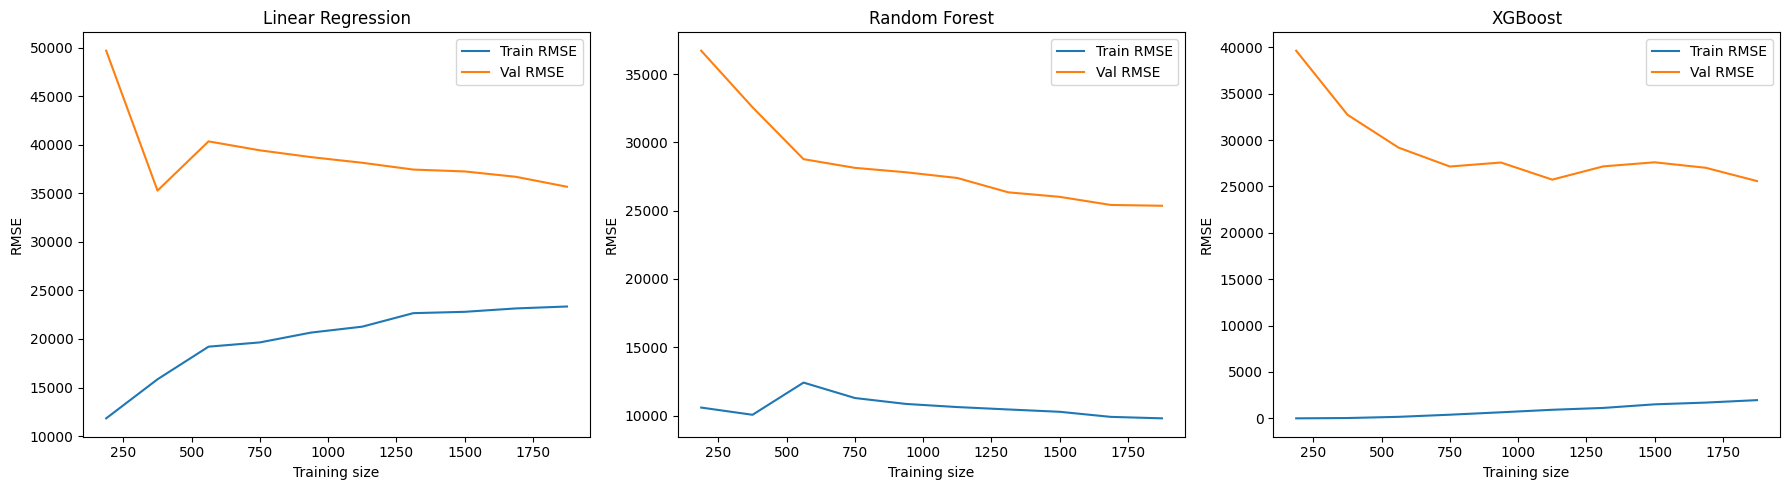

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_learning_curve(LinearRegression(), 'Linear Regression', axes[0])
plot_learning_curve(RandomForestRegressor(random_state=42), 'Random Forest', axes[1])
plot_learning_curve(XGBRegressor(random_state=42), 'XGBoost', axes[2])

plt.tight_layout()
plt.show()

### 5.4 Random Forest vs XGBoost

printing exact numbers so we can make proper conclusions instead of just eyeballing.

In [8]:
for name, model in [
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42))
]:
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train, y=y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.5, 1.0, 10),
        n_jobs=-1
    )

    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    print(f"\n{name}:")
    print(f"{'Size':>6} | {'Train RMSE':>12} | {'Val RMSE':>12} | {'Gap':>10}")
    print("-" * 48)
    for size, tr, vr in zip(train_sizes, train_rmse, val_rmse):
        print(f"{int(size):>6} | {tr:>12,.0f} | {vr:>12,.0f} | {vr-tr:>10,.0f}")


Random Forest:
  Size |   Train RMSE |     Val RMSE |        Gap
------------------------------------------------
   937 |       10,847 |       27,806 |     16,959
  1041 |       10,698 |       27,517 |     16,820
  1145 |       10,631 |       27,139 |     16,508
  1250 |       10,484 |       26,800 |     16,315
  1354 |       10,497 |       26,599 |     16,102
  1458 |       10,356 |       26,020 |     15,664
  1562 |       10,188 |       25,858 |     15,670
  1666 |        9,961 |       25,355 |     15,394
  1770 |        9,835 |       25,701 |     15,865
  1875 |        9,792 |       25,354 |     15,562

XGBoost:
  Size |   Train RMSE |     Val RMSE |        Gap
------------------------------------------------
   937 |          652 |       27,579 |     26,927
  1041 |          772 |       26,591 |     25,819
  1145 |          915 |       25,869 |     24,953
  1250 |        1,050 |       27,213 |     26,163
  1354 |        1,199 |       28,306 |     27,107
  1458 |        1,481 |   

### 5.5 Findings

**Linear Regression:**

High bias (underfitting). Train error goes UP as data increases — model is too simple
to capture the complexity of housing data. Adding more data won't fix this.
The model needs more complexity, not more data.


**Random Forest:**

Best bias-variance balance. Val error consistently going down (27,806 → 25,354).
Gap slowly closing. More data genuinely helps. Well-behaved and stable curves.
This is what a healthy learning curve looks like.


**XGBoost (default params):**

Overfitting heavily with default parameters. Train error almost zero (652 → 1,963)
while val error bounces around (25-28k). Gap is $23,617 — much larger than
Random Forest's 15,562.


**Conclusion:**

Random Forest has better natural bias-variance balance.
XGBoost overfits more but when properly tuned (Phase 4) it still wins on
final test performance (22,108 vs 24,255).
Lesson: boosting needs tuning, bagging is robust out of the box.


**Would more data help?**

Random Forest — yes, val curve still going down
XGBoost — yes but needs tuning first, raw overfitting is too high
Linear Regression — no, problem is model complexity not data size